# Short-term stock market prediction with Time Series Transformer Network	

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import sampler
import torch.optim as optim

from sklearn.model_selection import train_test_split

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
USE_GPU = True
device=None
dtype = torch.float32 # we will be using float throughout this tutorial

if USE_GPU and torch.mps.is_available():
    device = torch.device('mps')
elif USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('using device:', device)
# print(torch.cuda.device_count())
# print(torch.cuda.get_device_name(0))

using device: cuda


In [ ]:
# # Only run this once if merged_stock.csv does not exist. (takes 2 minutes to run)

# folder_path = 'datasets/2021'
# all_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

# merged_df = pd.concat([pd.read_csv(os.path.join(folder_path, file)).assign(stock=file[:-4]) for file in all_files])

# # Save the merged dataset
# merged_df.to_csv("datasets/merged_stocks.csv", index=False)
# merged_df.head()

# data_all = pd.read_csv("datasets/Kaggle_Dow_Jones_30_Historical_Data.csv")
# data_all.replace('?', 0, inplace=True)
# data_all.replace(np.nan, 0, inplace=True)



In [3]:
stock_df = pd.read_csv('datasets/merged_stocks.csv')
stock_df.head()

,ticker,name,date,open,high,low,close,adjusted close,volume,stock
0,A,"Agilent Technologies, Inc. Common Stock",2021-01-04 09:30:00-05:00,119.010002,120.089996,118.800003,120.019997,120.019997,0.0,A
1,A,"Agilent Technologies, Inc. Common Stock",2021-01-04 10:30:00-05:00,120.019997,120.029999,118.410004,118.860001,118.860001,341376.0,A
2,A,"Agilent Technologies, Inc. Common Stock",2021-01-04 11:30:00-05:00,118.839996,118.867996,117.269997,117.570000,117.570000,108887.0,A
3,A,"Agilent Technologies, Inc. Common Stock",2021-01-04 12:30:00-05:00,117.500000,118.260002,117.110001,118.099998,118.099998,90501.0,A
4,A,"Agilent Technologies, Inc. Common Stock",2021-01-04 13:30:00-05:00,118.120003,118.169998,117.750000,118.000000,118.000000,114713.0,A


In [4]:
# Check how many nans there are 
missing_values = (stock_df.isna().sum() / len(stock_df)) * 100
print(missing_values)
# stock_df.dropna(inplace=True)
# stock_df.isnull().any()

#data_all.isnull().values.any()

#data_all.isnull().any() #check for any NaN

#nan_rows = data_all[data_all['Walmart'].isnull()]
#data_all.columns

#DEBUG
#nans = test_data.isin([nan])

ticker            0.000000
name              0.000000
date              0.000000
open              0.003708
high              0.003708
low               0.003708
close             0.003708
adjusted close    0.003708
volume            0.003708
stock             0.000000
dtype: float64


In [5]:
# We see that there are less than a percent of nans, so we can drop them all
stock_df.dropna(inplace=True)

In [ ]:
#...

/var/folders/gh/j69cmlrs3ys39tqrjt2ww_hm0000gn/T/ipykernel_97759/1529601679.py:4: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  stock_df['date'] = pd.to_datetime(stock_df['date'], errors='coerce')


ticker             object
name               object
date               object
open              float64
high              float64
low               float64
close             float64
adjusted close    float64
volume            float64
stock              object
dtype: object


In [7]:
print(stock_df.dtypes)

ticker             object
name               object
date               object
open              float64
high              float64
low               float64
close             float64
adjusted close    float64
volume            float64
stock              object
dtype: object


In [6]:
# Normalize numeric features
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
stock_df[['open', 'high', 'low', 'close', 'adjusted close', 'volume']] = scaler.fit_transform(stock_df[['open', 'high', 'low', 'close', 'adjusted close', 'volume']])

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Set hyperparameters
window_length = 12
pred_length = 6  # Make length even to keep things simpler
batch_size = 512#1024

# Split into train and test datasets
split = 5700
train_data = stock_df.iloc[:split, :]
test_data = stock_df.iloc[split:, :]

def preprocess(data, window_length=window_length, pred_length=pred_length):
    # Keep only numeric columns (avoid ticker/name causing errors)
    numeric_columns = ["open", "high", "low", "close", "adjusted close", "volume"]
    data = data[numeric_columns].melt()["value"]

    # Convert to numeric, handling missing values
    data = pd.to_numeric(data, errors="coerce").fillna(method="ffill").to_numpy()  # Fill missing values

    # Normalize based on entire dataset (not per-window)
    data_min, data_max = np.min(data), np.max(data)
    data = (data - data_min) / (data_max - data_min + 1e-8)

    time_length = data.size
    x, y = [], []

    # Sequential slicing instead of random offsets
    for window_index in range(0, time_length - window_length - pred_length, window_length):
        window = data[window_index:window_index + window_length]
        
        x.append(window[:pred_length])  # First part as input
        y.append(window[pred_length:])  # Second part as target

    x, y = np.asarray(x), np.asarray(y)

    # Reshape for transformers (batch_size, seq_length, num_features)
    x = np.reshape(x, [x.shape[0], x.shape[1], 1])
    y = np.reshape(y, [y.shape[0], y.shape[1], 1])

    # Apply positional encoding to ALL sequences
    dim_model = 1
    max_len = pred_length
    position_encoding = np.zeros([max_len, dim_model], dtype=np.float32)
    position_list = np.reshape(np.arange(0, max_len, dtype=np.float32), [-1, 1])
    denominator = np.exp(-np.log(10000.0) * np.arange(0, dim_model, 2, dtype=np.float32)/dim_model)
    position_encoding[:, 0::2] = np.sin(position_list / denominator)
    position_encoding[:, 1::2] = np.cos(position_list / denominator)

    # Apply encoding to ALL sequences, not just x[0]
    for i in range(x.shape[0]):
        x[i, :, 0] = position_encoding[:, 0]
        y[i, :, 0] = position_encoding[:, 0]

    return x, y

# Process training and test datasets
x_train, y_train = preprocess(train_data)
x_test, y_test = preprocess(test_data)

# Create DataLoaders
train_loader = DataLoader(list(zip(x_train, y_train)), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(list(zip(x_test, y_test)), batch_size=batch_size, shuffle=False)  # Keep shuffle=False for testing


# PREVIOUS CODE IS BELOW HERE

# window_length=12 
# pred_length=6 #make len even to keep things simpler
# batch_size = 1024#512 #too big?

# #split into train and test datasets
# split = 5700
# train_data = stock_df.iloc[:split, :]
# test_data = stock_df.iloc[split:, :] 

# def preprocess(data, window_length = window_length, pred_length = pred_length):
#     #flatten all stocks into one column  
#     data = data.iloc[:, 1:].melt()
#     data = data.iloc[:, 1]
    
#     data = pd.to_numeric(data).to_numpy() #faster to do slicing operation as numpy array than pandas
#     time_length = data.size

#     #split into sections of length window_length, normalize, then put first half in x and second half in y
#     x = [] 
#     y = []
#     for window_index in np.arange( np.random.randint(0,window_length-1), time_length-window_length-pred_length, window_length):  
#         window = np.array(data[window_index:window_index+window_length])
#         window = window-np.min(window) 
#         window = window/np.max(window)

#         x.append(window[0:pred_length])
#         y.append(window[pred_length:window_length])
     
#     x = np.asarray(x)
#     y = np.asarray(y)

#     #add positional enccoding
#     x = np.reshape(x, [x.shape[0], x.shape[1], 1])#reshape into N, S, E where S is the source sequence length, T is the target sequence length, N is the batch size, EE is the feature number
#     y = np.reshape(y, [y.shape[0], y.shape[1], 1]) 

#     dim_model = 1 #number of features
#     max_len = pred_length 

#     position_encoding = np.zeros([max_len, dim_model], dtype=np.float32)
#     position_list = np.reshape(np.arange(0, max_len, dtype=np.float32), [-1, 1])
#     denominator = np.exp(-np.log(10000.0) * np.arange(0, dim_model, 2, dtype=np.float32)/dim_model) 
#     position_encoding[:, 0::2] = np.sin(position_list / denominator)
#     position_encoding[:, 1::2] = np.cos(position_list / denominator)

#     plt.imshow(position_encoding)
#     plt.figure()

#     x[0, :, 0] = position_encoding[:, 0] #replace 2nd dim with positional encodings
#     y[0, :, 0] = position_encoding[:, 0]
    
#     return x, y


# x_train, y_train = preprocess(train_data)
# x_test, y_test = preprocess(test_data)

# # print(x_train.shape)
# # print(y_train.shape)
# # print(x_train.dtype)

# train_loader = DataLoader(list(zip(x_train, y_train)), batch_size, shuffle=True) #x is same as y for simple scalar transformers, right?
# test_loader = DataLoader(list(zip(x_test, y_test)), batch_size, shuffle=True)

C:\Users\ebook\AppData\Local\Temp\ipykernel_41200\3357829863.py:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = pd.to_numeric(data, errors="coerce").fillna(method="ffill").to_numpy()  # Fill missing values
C:\Users\ebook\AppData\Local\Temp\ipykernel_41200\3357829863.py:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = pd.to_numeric(data, errors="coerce").fillna(method="ffill").to_numpy()  # Fill missing values


In [10]:
print(x_test.shape)
print(x_test[:, 0, :])

(3003354, 15, 1)
[[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]


In [ ]:
# window_size = 16
# forecast_length = 16
# num_val = 2

# data_all['date'] = pd.to_datetime(data_all['date']) #convert int to datetime
# val_max_date = '2017-08-15'
# train_max_date = str((pd.to_datetime(val_max_date) - pd.Timedelta(days=window_size*num_val+forecast_length)).date())

# train_final = data_all[data_all['date']<=train_max_date]
# val_final = data_all[(data_all['date']>train_max_date)&(data_all['date']<=val_max_date)]

# train_series = train_final.groupby(categorical_static).agg(list).reset_index()
# val_series = val_final.groupby(categorical_static).agg(list).reset_index()

# #try changing date to ints
# train_series
# data_all['date'] = pd.to_datetime(data_all['date']) #convert int to datetime

In [ ]:
# def divide_shuffle(df,div_num):
#     space = df.shape[0]//div_num
#     division = np.arange(0,df.shape[0],space)
#     return pd.concat([df.iloc[division[i]:division[i]+space,:].sample(frac=1) for i in range(len(division))])

# def create_time_blocks(time_length,window_size,forecast_length):
#     start_idx = np.random.randint(0,window_size-1)
#     end_idx = time_length-window_size-forecast_length-1
#     time_indices = np.arange(start_idx,end_idx+1,window_size)[:-1]
#     time_indices = np.append(time_indices,end_idx)
#     return time_indices

# def data_loader(x_numeric_tensor, x_category_tensor, x_static_tensor, y_tensor, batch_size, time_shuffle):

#     num_series = x_numeric_tensor.shape[0]
#     time_length = x_numeric_tensor.shape[1]
#     index_pd = pd.DataFrame({'serie_idx':range(num_series)})
#     index_pd['time_idx'] = [create_time_blocks(time_length,window_size,forecast_length) for n in range(index_pd.shape[0])]
#     if time_shuffle:
#         index_pd = index_pd.explode('time_idx')
#         index_pd = index_pd.sample(frac=1)
#     else:
#         index_pd = index_pd.explode('time_idx').sort_values('time_idx')
#         index_pd = divide_shuffle(index_pd,5)
#     indices = np.array(index_pd).astype(int)

#     for batch_idx in np.arange(0,indices.shape[0],batch_size):

#         cur_indices = indices[batch_idx:batch_idx+batch_size,:]

#         x_numeric = torch.stack([x_numeric_tensor[n[0],n[1]:n[1]+window_size,:] for n in cur_indices])
#         x_category = torch.stack([x_category_tensor[n[0],n[1]:n[1]+window_size,:] for n in cur_indices])
#         x_static = torch.stack([x_static_tensor[n[0],:] for n in cur_indices])
#         y = torch.stack([y_tensor[n[0],n[1]+window_size:n[1]+window_size+forecast_length] for n in cur_indices])

#         yield x_numeric.to(device), x_category.to(device), x_static.to(device), y.to(device)

# def val_loader(x_numeric_tensor, x_category_tensor, x_static_tensor, y_tensor, batch_size, num_val):

#     num_time_series = x_numeric_tensor.shape[0]

#     for i in range(num_val):

#       for batch_idx in np.arange(0,num_time_series,batch_size):

#           x_numeric = x_numeric_tensor[batch_idx:batch_idx+batch_size,window_size*i:window_size*(i+1),:]
#           x_category = x_category_tensor[batch_idx:batch_idx+batch_size,window_size*i:window_size*(i+1),:]
#           x_static = x_static_tensor[batch_idx:batch_idx+batch_size]
#           y_val = y_tensor[batch_idx:batch_idx+batch_size,window_size*(i+1):window_size*(i+1)+forecast_length]

#           yield x_numeric.to(device), x_category.to(device), x_static.to(device), y_val.to(device)

In [ ]:
# #medium model
# #don't need to run this block
# class transformer_block(nn.Module):

#     def __init__(self,embed_size,num_heads):
#         super(transformer_block, self).__init__()

#         self.attention = nn.MultiheadAttention(embed_size, num_heads, batch_first=True)
#         self.fc = nn.Sequential(nn.Linear(embed_size, 4 * embed_size),
#                                  nn.LeakyReLU(),
#                                  nn.Linear(4 * embed_size, embed_size))
#         self.dropout = nn.Dropout(drop_prob)
#         self.ln1 = nn.LayerNorm(embed_size, eps=1e-6)
#         self.ln2 = nn.LayerNorm(embed_size, eps=1e-6)

#     def forward(self, x):

#         attn_out, _ = self.attention(x, x, x, need_weights=False)
#         x = x + self.dropout(attn_out)
#         x = self.ln1(x)

#         fc_out = self.fc(x)
#         x = x + self.dropout(fc_out)
#         x = self.ln2(x)

#         return x


# class transformer_forecaster(nn.Module):

#     def __init__(self,embed_size,num_heads,num_blocks):
#         super(transformer_forecaster, self).__init__()

#         num_len = len(numeric_covariates)
#         self.embedding_cov = nn.ModuleList([nn.Embedding(n,embed_size-num_len) for n in categorical_covariates_num_embeddings])
#         self.embedding_static = nn.ModuleList([nn.Embedding(n,embed_size-num_len) for n in categorical_static_num_embeddings])

#         self.blocks = nn.ModuleList([transformer_block(embed_size,num_heads) for n in range(num_blocks)])

#         self.forecast_head = nn.Sequential(nn.Linear(embed_size, embed_size*2),
#                                            nn.LeakyReLU(),
#                                            nn.Dropout(drop_prob),
#                                            nn.Linear(embed_size*2, embed_size*4),
#                                            nn.LeakyReLU(),
#                                            nn.Linear(embed_size*4, forecast_length),
#                                            nn.ReLU())

#     def forward(self, x_numeric, x_category, x_static):

#         tmp_list = []
#         for i,embed_layer in enumerate(self.embedding_static):
#             tmp_list.append(embed_layer(x_static[:,i]))
#         categroical_static_embeddings = torch.stack(tmp_list).mean(dim=0).unsqueeze(1)

#         tmp_list = []
#         for i,embed_layer in enumerate(self.embedding_cov):
#             tmp_list.append(embed_layer(x_category[:,:,i]))
#         categroical_covariates_embeddings = torch.stack(tmp_list).mean(dim=0)
#         T = categroical_covariates_embeddings.shape[1]

#         embed_out = (categroical_covariates_embeddings + categroical_static_embeddings.repeat(1,T,1))/2
#         x = torch.concat((x_numeric,embed_out),dim=-1)

#         for block in self.blocks:
#             x = block(x)

#         x = x.mean(dim=1)
#         x = self.forecast_head(x)

#         return x
    



# class RMSLELoss(nn.Module):

#     def __init__(self):
#         super().__init__()
#         self.mse = nn.MSELoss()

#     def forward(self, pred, actual):
#         return torch.sqrt(self.mse(torch.log(pred + 1), torch.log(actual + 1)))

In [8]:
class MyTransformerWrapper(nn.Module):
    def __init__(self, d_model=32, nhead=1, num_encoder_layers=6, num_decoder_layers=6): #32 to 64 dims #nhead from 1 to 8
        super().__init__()
        
        self.input_projection = nn.Linear(1, d_model)
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            batch_first=True
        )
        self.output_projection = nn.Linear(d_model, 1)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None,
                src_is_causal=False, tgt_is_causal=False):
        
        src_emb = self.input_projection(src)  # shape: (B, S, 1) -> (B, S, d_model)
        tgt_emb = self.input_projection(tgt)  # shape: (B, T, 1) -> (B, T, d_model)

        transformer_out = self.transformer(
            src_emb, 
            tgt_emb,
            src_mask=src_mask, 
            tgt_mask=tgt_mask,
            src_is_causal=src_is_causal,
            tgt_is_causal=tgt_is_causal
        )  # shape: (B, T, d_model)

        out = self.output_projection(transformer_out)  # shape: (B, T, d_model) -> (B, T, 1)
        return out

In [10]:
#Pytorch vanilla transformer with MSE loss

# transformer_model = nn.Transformer(d_model = 1, nhead=1, num_encoder_layers=6, num_decoder_layers=6, batch_first=True, device=device) #only 1 head bc of 1 input dimension
# src = torch.rand((batch_size, window_length, 1)).to(device=device, dtype=dtype)#10, 32, 512)) #replace w ...
# tgt = torch.rand((batch_size, pred_length, 1)).to(device=device, dtype=dtype)#20, 32, 512))
# out = transformer_model(src, tgt).to(device=device, dtype=dtype) #MOVE TO CPU DEVICE????
# print(src.dtype)

class RMSLELoss(nn.Module):

    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()

    def forward(self, pred, actual):
        return self.mse(pred, actual)
        #return torch.sqrt(self.mse(torch.log(pred + 1), torch.log(actual + 1))) #requires relu after final layer to avoid negative predictions from log loss

In [11]:
#train the damn thing
train_losses = []
val_losses = []

num_epoch = 10#1000
min_val_loss = 1
data_folder = 'saved_models/'

learning_rate = 3.5e-4 #try smaller lr
time_shuffle = False
drop_prob = 0.1

model = MyTransformerWrapper(
    d_model=32, 
    nhead=1, 
    num_encoder_layers=6, 
    num_decoder_layers=6
).to(device)

criterion = RMSLELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
training_loss = []
validation_loss = []
for epoch in range(num_epoch):
    
    model.train()
    train_loss = 0
    counter = 0
    mask = nn.Transformer.generate_square_subsequent_mask(sz=pred_length, device=device) #generate casual mask #WAIT.... DIFFERENT MASK SIZES NOT GIVING ERROR
    
    for x_batch, y_batch in train_loader: 
        x_batch = x_batch.to(device=device, dtype=dtype)
        y_batch = y_batch.to(device=device, dtype=dtype)
       
        pred = model(x_batch, y_batch, src_mask=mask, tgt_mask=mask, src_is_causal=True, tgt_is_causal=True).to(device=device)  #is the the correct place to enter the forward() parameters?
        #pred = model(x_batch, y_batch)#, src_mask=mask, tgt_mask=mask, src_is_causal=True, tgt_is_causal=True)  #is the the correct place to enter the forward() parameters?
        loss = criterion(pred, y_batch).to(device=device)
        #print("loss:")
        #print(loss)
        optimizer.zero_grad()
        train_loss += loss.item()
        counter += 1
        loss.backward()

        # print("pred:")
        # print(pred)
        # print("y_batch:")
        # print(y_batch)
        # Print gradients- ********************************8
        # for name, param in model.named_parameters():
        #     if param.grad is not None:
        #         print(f"{name} grad mean: {param.grad.mean().item():.6f}, "
        #               f"std: {param.grad.std().item():.6f}")
        #     else:
        #         print(f"{name} grad is None")

        optimizer.step()

    train_loss = train_loss/counter
    training_loss.append(train_loss)
    print(f'Epoch {epoch} training loss: {train_loss}')

    model.eval()
    val_loss = 0
    counter = 0
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device=device, dtype=dtype)
        y_batch = y_batch.to(device=device, dtype=dtype)
        with torch.no_grad():
            pred = model(x_batch, y_batch, src_mask=mask, tgt_mask=mask, src_is_causal=True, tgt_is_causal=True)
            #pred = model(x_batch, y_batch)#, src_mask=mask, tgt_mask=mask, src_is_causal=True, tgt_is_causal=True)  #is the the correct place to enter the forward() parameters?
            loss = criterion(pred,y_batch).item()
        val_loss += loss
        counter += 1
    val_loss = val_loss/counter
    print(f'Epoch {epoch} validation loss: {val_loss}')

    # for plotting train and val
    train_losses.append(train_loss)
    validation_loss.append(val_loss)
    val_losses.append(val_loss)


    if val_loss<min_val_loss:
      print('saved...')
      torch.save(model,data_folder+'best.model')
      min_val_loss = val_loss

    scheduler.step()

Epoch 0 training loss: 0.9645244975884756


KeyboardInterrupt: 

In [ ]:
# Plot the training loss function and validation accuracies
plt.subplot(2, 1, 1)
plt.plot(training_loss)
plt.title("Training Loss History")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(2, 1, 2)
# plt.plot(stats['train_acc_history'], label='train')
plt.plot(validation_loss, label="val")
plt.title("Validation Loss History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [ ]:
# #save the model
# print("Model's state_dic:")
# for param_tensor in model.state_dic():
#     print(param_tensor, "\t", model.state_dict()[param_tensor].size())

# torch.save(model.state_dict(), 'saved_models/toy_model.pt')

In [15]:
#test the model
data_folder = 'saved_models/'
model = torch.load(data_folder+'best.model', weights_only=False)
                   
truth_plot_data = torch.empty((0,pred_length,1))       #save data for visualization
pred_plot_data = torch.empty((0,pred_length,1))  #save data for visualization
truth_plot_data = truth_plot_data.to(device=device, dtype=dtype)
pred_plot_data = pred_plot_data.to(device=device, dtype=dtype)

model.eval()
val_loss = 0
counter = 0
for x_batch, y_batch in test_loader:
    x_batch = x_batch.to(device=device, dtype=dtype)
    y_batch = y_batch.to(device=device, dtype=dtype)
    truth_plot_data = torch.cat((truth_plot_data, y_batch))
    with torch.no_grad():
        pred = model(x_batch, y_batch, src_mask=mask, tgt_mask=mask, src_is_causal=True, tgt_is_causal=True)
        #pred = model(x_batch, y_batch)#, src_mask=mask, tgt_mask=mask, src_is_causal=True, tgt_is_causal=True)  #is the the correct place to enter the forward() parameters?
        loss = criterion(pred,y_batch).item()
        pred_plot_data = torch.cat((pred_plot_data, pred))
    val_loss += loss
    counter += 1
val_loss = val_loss/counter
print(f'Test loss: {val_loss}')

truth_plot_data = truth_plot_data.cpu()
pred_plot_data = pred_plot_data.cpu()

Test loss: 0.6120685935183012


In [16]:
pred_plot_data.shape
pred_plot_data

tensor([[[-0.3400],
         [-0.3130],
         [-0.3138],
         [-0.3466],
         [-0.3723],
         [-0.3738]],

        [[-0.3400],
         [-0.3130],
         [-0.3138],
         [-0.3466],
         [-0.3723],
         [-0.3738]],

        [[-0.3400],
         [-0.3130],
         [-0.3138],
         [-0.3466],
         [-0.3723],
         [-0.3738]],

        ...,

        [[-0.3400],
         [-0.3130],
         [-0.3138],
         [-0.3466],
         [-0.3723],
         [-0.3738]],

        [[-0.3400],
         [-0.3130],
         [-0.3138],
         [-0.3466],
         [-0.3723],
         [-0.3738]],

        [[-0.3400],
         [-0.3130],
         [-0.3138],
         [-0.3466],
         [-0.3723],
         [-0.3738]]])

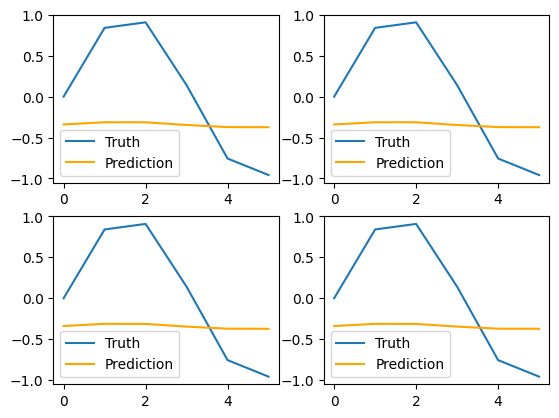

In [17]:
#truth_plot_data.shape
x_count = 2
y_count = 2
fig, axs = plt.subplots(x_count, y_count)

count = 0
for a in range(x_count):
    for b in range(y_count):
        axs[a, b].plot(truth_plot_data[count])
        axs[a, b].plot(pred_plot_data[count], 'orange')
        axs[a, b].legend(['Truth', 'Prediction'])
        count = count + 1

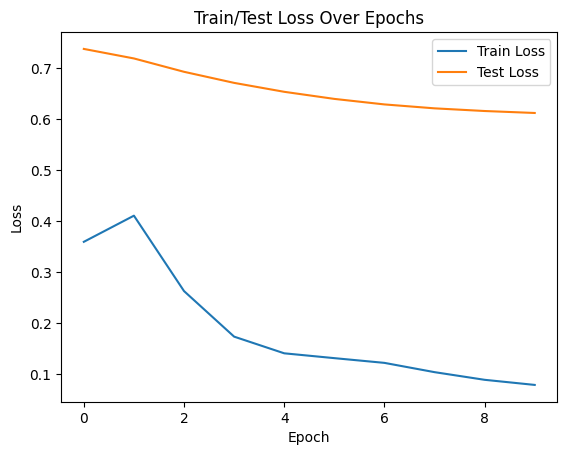

In [18]:
# Plot loss curves
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Train/Test Loss Over Epochs')
plt.show()